In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler


In [3]:
df = pd.read_csv('/users/imbahndu/Desktop/Columbia DBM/Typing dataset/typing.csv', low_memory=False)

In [4]:
df.head()

,Unnamed: 0,UserKey,Date,Timestamp,Hand,HoldTime,Direction,LatencyTime,FlightTime,Filename,...,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other
0,0,0EA27ICBLF,160722,18:41:04.336,L,0101.6,LL,0234.4,0156.3,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
1,1,0EA27ICBLF,160722,18:42:14.070,L,0085.9,LL,0437.5,0359.4,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
2,2,0EA27ICBLF,160722,18:42:14.273,L,0078.1,LL,0210.9,0125.0,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
3,3,0EA27ICBLF,160722,18:42:14.617,L,0062.5,LL,0359.4,0281.3,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
4,4,0EA27ICBLF,160722,18:42:15.586,S,0125.0,LS,0187.5,0093.8,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False


In [5]:
#Finding out the number of missing values
null_series = df.isnull().sum()

print(null_series)

print(type(null_series))

Unnamed: 0             0
UserKey                0
Date                   0
Timestamp              0
Hand                   0
HoldTime               0
Direction              0
LatencyTime            0
FlightTime             2
Filename               0
BirthYear        2153339
Gender            301987
Parkinsons        301987
Tremors           301987
DiagnosisYear    1469539
Sided            3498254
UPDRS             301987
Impact            480998
Levadopa          301987
DA                301987
MAOB              301987
Other             301987
dtype: int64
<class 'pandas.core.series.Series'>


In [6]:
#Dropping all the rows with couts 301987
rows_to_drop = []
for col in range(len(null_series)):
    if null_series[col] == 301987:
        rows_to_drop.append(col)

columns = [] 
for row in rows_to_drop:
    columns.append(df.columns[row])

print(columns)

df = df.dropna(subset = columns)
print(df)

['Gender', 'Parkinsons', 'Tremors', 'UPDRS', 'Levadopa', 'DA', 'MAOB', 'Other']


/tmp/ipykernel_2765558/2088116909.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if null_series[col] == 301987:


         Unnamed: 0     UserKey    Date     Timestamp Hand HoldTime Direction  \
0                 0  0EA27ICBLF  160722  18:41:04.336    L   0101.6        LL   
1                 1  0EA27ICBLF  160722  18:42:14.070    L   0085.9        LL   
2                 2  0EA27ICBLF  160722  18:42:14.273    L   0078.1        LL   
3                 3  0EA27ICBLF  160722  18:42:14.617    L   0062.5        LL   
4                 4  0EA27ICBLF  160722  18:42:15.586    S   0125.0        LS   
...             ...         ...     ...           ...  ...      ...       ...   
9316853     9316853  ZYWLN4JVLA  170126  13:56:20.117    L   0195.3        RL   
9316854     9316854  ZYWLN4JVLA  170126  13:56:20.242    R   0105.5        LR   
9316855     9316855  ZYWLN4JVLA  170126  13:56:33.625    L   0168.0        LL   
9316856     9316856  ZYWLN4JVLA  170126  13:56:33.836    L   0097.7        LL   
9316857     9316857  ZYWLN4JVLA  170126  13:56:34.066    L   0168.0        LL   

        LatencyTime FlightT

In [7]:
#Verifying if code worked and all rows with 301987
df.isnull().sum()

Unnamed: 0             0
UserKey                0
Date                   0
Timestamp              0
Hand                   0
HoldTime               0
Direction              0
LatencyTime            0
FlightTime             2
Filename               0
BirthYear        1851352
Gender                 0
Parkinsons             0
Tremors                0
DiagnosisYear    1167552
Sided            3196267
UPDRS                  0
Impact            179011
Levadopa               0
DA                     0
MAOB                   0
Other                  0
dtype: int64

In [8]:
#Dropping the unnamed column --> don't see why it's necessary
df.drop(columns = "Unnamed: 0")

,UserKey,Date,Timestamp,Hand,HoldTime,Direction,LatencyTime,FlightTime,Filename,BirthYear,...,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other
0,0EA27ICBLF,160722,18:41:04.336,L,0101.6,LL,0234.4,0156.3,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
1,0EA27ICBLF,160722,18:42:14.070,L,0085.9,LL,0437.5,0359.4,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
2,0EA27ICBLF,160722,18:42:14.273,L,0078.1,LL,0210.9,0125.0,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
3,0EA27ICBLF,160722,18:42:14.617,L,0062.5,LL,0359.4,0281.3,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
4,0EA27ICBLF,160722,18:42:15.586,S,0125.0,LS,0187.5,0093.8,0EA27ICBLF_1607.txt,1952.0,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9316853,ZYWLN4JVLA,170126,13:56:20.117,L,0195.3,RL,0425.8,261.7,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316854,ZYWLN4JVLA,170126,13:56:20.242,R,0105.5,LR,0214.8,19.5,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316855,ZYWLN4JVLA,170126,13:56:33.625,L,0168.0,LL,0332.0,15.6,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316856,ZYWLN4JVLA,170126,13:56:33.836,L,0097.7,LL,0281.3,113.3,ZYWLN4JVLA_1701.txt,NaN,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True


In [9]:
#Still left with 9M rows, so deleting columns with duplicates userkeys 

#df = df.drop_duplicates(subset=["UserKey"])
#df = df.groupby("UserKey").head(100).reset_index(drop=True)

In [10]:
df

,Unnamed: 0,UserKey,Date,Timestamp,Hand,HoldTime,Direction,LatencyTime,FlightTime,Filename,...,Parkinsons,Tremors,DiagnosisYear,Sided,UPDRS,Impact,Levadopa,DA,MAOB,Other
0,0,0EA27ICBLF,160722,18:41:04.336,L,0101.6,LL,0234.4,0156.3,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
1,1,0EA27ICBLF,160722,18:42:14.070,L,0085.9,LL,0437.5,0359.4,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
2,2,0EA27ICBLF,160722,18:42:14.273,L,0078.1,LL,0210.9,0125.0,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
3,3,0EA27ICBLF,160722,18:42:14.617,L,0062.5,LL,0359.4,0281.3,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
4,4,0EA27ICBLF,160722,18:42:15.586,S,0125.0,LS,0187.5,0093.8,0EA27ICBLF_1607.txt,...,True,True,2000,Left,Don't know,Severe,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9316853,9316853,ZYWLN4JVLA,170126,13:56:20.117,L,0195.3,RL,0425.8,261.7,ZYWLN4JVLA_1701.txt,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316854,9316854,ZYWLN4JVLA,170126,13:56:20.242,R,0105.5,LR,0214.8,19.5,ZYWLN4JVLA_1701.txt,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316855,9316855,ZYWLN4JVLA,170126,13:56:33.625,L,0168.0,LL,0332.0,15.6,ZYWLN4JVLA_1701.txt,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True
9316856,9316856,ZYWLN4JVLA,170126,13:56:33.836,L,0097.7,LL,0281.3,113.3,ZYWLN4JVLA_1701.txt,...,True,False,NaN,Right,Don't know,Medium,True,True,True,True


In [11]:
df["Parkinsons"].value_counts()

Parkinsons
True     6470722
False    2544149
Name: count, dtype: int64

In [12]:
#Checking the URPDS column
df["UPDRS"].value_counts()

UPDRS
Don't know    8203052
4              717717
3               68171
2               25922
1                   9
Name: count, dtype: int64

In [13]:
df["UPDRS"] = df["UPDRS"].replace("Don't know", 0)

In [14]:
df["Parkinsons"].value_counts()

Parkinsons
True     6470722
False    2544149
Name: count, dtype: int64

In [15]:
# Filter rows where UPDRS is "Don't know"
subset = df[df["UPDRS"] == 0]

# Count Parkinson's True vs False
counts = subset["Parkinsons"].value_counts()
print(counts)

Parkinsons
True     5658903
False    2544149
Name: count, dtype: int64


In [16]:
#Dropping columns (both categorical and numerical col) that will not impact a model
df = df.drop(columns = ["BirthYear", "UserKey", "Tremors", "DiagnosisYear", "Sided", "Impact", "Levadopa", "MAOB", "DA", "Other", "Unnamed: 0", "Date", "Filename", "Timestamp"])

In [17]:
#One hot enconding teh gender
df = pd.get_dummies(df, columns=["Gender"],drop_first=True)

In [18]:
df["Parkinsons"].value_counts()

Parkinsons
True     6470722
False    2544149
Name: count, dtype: int64

In [19]:
df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,UPDRS,Gender_Male
0,L,0101.6,LL,0234.4,0156.3,True,0,False
1,L,0085.9,LL,0437.5,0359.4,True,0,False
2,L,0078.1,LL,0210.9,0125.0,True,0,False
3,L,0062.5,LL,0359.4,0281.3,True,0,False
4,S,0125.0,LS,0187.5,0093.8,True,0,False
...,...,...,...,...,...,...,...,...
9316853,L,0195.3,RL,0425.8,261.7,True,0,False
9316854,R,0105.5,LR,0214.8,19.5,True,0,False
9316855,L,0168.0,LL,0332.0,15.6,True,0,False
9316856,L,0097.7,LL,0281.3,113.3,True,0,False


In [20]:
print(df["Hand"].unique())

['L' 'S' 'R' '160725' '160809' '160813' '23:17:06.555' '170221' '170228'
 '14:01:21.672' '3MZWDTW7CC' '08:40:34.025' '17:38:13.930' '5ARV4LHEJ0'
 '16:17:54.109' '02:20:42.267' '170203' '20:40:00.594' '19:49:06.688'
 '161001' 'L8EY6NZAKCI' '170201' 'R95S93AXF86' '170212' '170215' '170218'
 '170220' '170222' '170223' '170226' '95S93AXF86' '170302' '170209'
 '160814' '160817' '14:07:18.391' '160820' '160822' '160823' '160824'
 '160826' '160827' '160829' '160830' '160831' 'AFNOZ1KI1M' '160904'
 '160905' '11:22:30.074' '160921' '160924' '160925' '160926'
 '07:20:50.789' '10:02:07.637' '161128' 'LAFQWSP8ARK' '160726' '160912'
 '12:01:03.844' '170107' '170115' '15:38:02.125' '11:25:55.363' '161010'
 '170103' '170217' '170225' '161223' '161116' '20:44:51.438' 'FXC5YFXZ0K'
 '170120' '11:37:59.215' '170207' '17:12:53.633' '160805' '160812'
 '160901' '07:54:11.604' '160908' '160911' '11:46:48.309' '160923'
 '170211' '170126' '23:52:20.352' '160808' '10:28:47.816' '160816'
 '08:26:14.389' '07:43:4

In [21]:
print(df["Direction"].unique())

['LL' 'LS' 'SL' 'LR' 'RR' 'RL' 'RS' 'SR' 'SS' '160725' 'L' 'L0EA27ICBLF'
 'S' '0156.3' '170225' '0253.9' '09:21:16.109' '0171.9' '0187.5'
 '09:15:01.008' 'RR3MZWDTW7CC' '160929' '12:20:50.980' '0121.1' '0139.6'
 'LL6WBXSDG5BB' 'L6WBXSDG5BB' '170203' '81NEUZEBXI' '0218.8' 'R'
 '05:15:55.525' '170213' '95S93AXF86' '10:59:11.953' '170224'
 '14:16:13.559' 'AFNOZ1KI1M' '160818' '0128.9' '160825' '160827'
 'SRAFNOZ1KI1M' 'RAFNOZ1KI1M' '15:32:50.891' '160903' '160919' '0146.5'
 '0191.4' '09:50:19.398' '0125.0' '0031.3' '0105.5' '170121' '160811'
 '161007' 'FHEOPKL3QQ' '161028' '0140.6' '11:48:00.484' '161125' '0101.6'
 '160809' '0080.1' '0074.2' '160802' '160806' '160815' '0056.6' '0160.2'
 '160908' '0085.9' '14:14:07.031' 'LLJMIVIRFQRR' '160726' '160727'
 '0001.0' '0127.9' 'LJMIVIRFQRR' '160823' '160828' 'JMIVIRFQRR'
 '21:44:15.812' '0078.1' '07:53:31.539' 'RRJMIVIRFQRR' '0070.3' '0104.0'
 '16:15:37.516' 'LLJMYZ5IKGWE' '0113.3' 'KTUVFFSLN4' '160821'
 '18:12:51.539' '161127' '0210.9' '161118'

In [22]:
#Dropping rows with weird labels for categorical columns, hands and directions
correct_hands = ["L", "R"]

for col in correct_hands:

    df = df[df["Hand"].isin(correct_hands)]

df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,UPDRS,Gender_Male
0,L,0101.6,LL,0234.4,0156.3,True,0,False
1,L,0085.9,LL,0437.5,0359.4,True,0,False
2,L,0078.1,LL,0210.9,0125.0,True,0,False
3,L,0062.5,LL,0359.4,0281.3,True,0,False
5,L,0078.1,SL,0226.6,0101.6,True,0,False
...,...,...,...,...,...,...,...,...
9316853,L,0195.3,RL,0425.8,261.7,True,0,False
9316854,R,0105.5,LR,0214.8,19.5,True,0,False
9316855,L,0168.0,LL,0332.0,15.6,True,0,False
9316856,L,0097.7,LL,0281.3,113.3,True,0,False


In [23]:
#Verifying if I got rid of all weird  numbers
print(df["Hand"].value_counts())

print(df["Hand"].unique())

Hand
L    4245766
R    3198166
Name: count, dtype: int64
['L' 'R']


In [24]:
#Doing thesame thing for direction 

correct_directions = ["LL","LR" ,"RR", "RL"]

for col in correct_directions:

    df = df[df["Direction"].isin(correct_directions)]

df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,UPDRS,Gender_Male
0,L,0101.6,LL,0234.4,0156.3,True,0,False
1,L,0085.9,LL,0437.5,0359.4,True,0,False
2,L,0078.1,LL,0210.9,0125.0,True,0,False
3,L,0062.5,LL,0359.4,0281.3,True,0,False
6,R,0085.9,LR,0195.3,0117.2,True,0,False
...,...,...,...,...,...,...,...,...
9316853,L,0195.3,RL,0425.8,261.7,True,0,False
9316854,R,0105.5,LR,0214.8,19.5,True,0,False
9316855,L,0168.0,LL,0332.0,15.6,True,0,False
9316856,L,0097.7,LL,0281.3,113.3,True,0,False


In [25]:
df["UPDRS"] = df["UPDRS"].astype(int)

In [26]:
df["UPDRS"].dtype

dtype('int64')

 LightBGM modeling-specific Label Encoding Categorical Variables 

In [27]:
#LabelEncoding these values --> For future app, this would be helpful

cat_columns = ["Hand", "Direction"]

from sklearn.preprocessing import LabelEncoder

#Calling the module, fitting for each cat variables

for col in df[cat_columns]:

    label_encoder = LabelEncoder()

    df[col] = label_encoder.fit_transform(df[col])
    
    print(df[col].unique())


[0 1]
[0 1 3 2]


In [28]:
print(df["Hand"].unique())

[0 1]


In [29]:
print(df["Direction"])

0          0
1          0
2          0
3          0
6          1
          ..
9316853    2
9316854    1
9316855    0
9316856    0
9316857    0
Name: Direction, Length: 6237183, dtype: int64


In [30]:
#Printing the types of all columns
print(df.dtypes)


Hand            int64
HoldTime       object
Direction       int64
LatencyTime    object
FlightTime     object
Parkinsons     object
UPDRS           int64
Gender_Male      bool
dtype: object


In [31]:
#Drooping the expected numerical columns to float
expected_numerical = ["HoldTime", "LatencyTime", "FlightTime"]

# Convert columns to numeric, else convert them to NAN
for col in expected_numerical:

    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaN in any of the expected numeric columns
df.dropna(subset=expected_numerical, inplace=True)


In [32]:
#Printing out the numerical col for tailo
for num in expected_numerical:
    print()
    print(df[num])
    print()


0          101.6
1           85.9
2           78.1
3           62.5
6           85.9
           ...  
9316853    195.3
9316854    105.5
9316855    168.0
9316856     97.7
9316857    168.0
Name: HoldTime, Length: 6236976, dtype: float64


0          234.4
1          437.5
2          210.9
3          359.4
6          195.3
           ...  
9316853    425.8
9316854    214.8
9316855    332.0
9316856    281.3
9316857    160.2
Name: LatencyTime, Length: 6236976, dtype: float64


0          156.3
1          359.4
2          125.0
3          281.3
6          117.2
           ...  
9316853    261.7
9316854     19.5
9316855     15.6
9316856    113.3
9316857     62.5
Name: FlightTime, Length: 6236976, dtype: float64



In [33]:
#Converting the string literal of PD to bool 

df["Parkinsons"] = df["Parkinsons"].astype(bool)

In [34]:
print(df.dtypes)

Hand             int64
HoldTime       float64
Direction        int64
LatencyTime    float64
FlightTime     float64
Parkinsons        bool
UPDRS            int64
Gender_Male       bool
dtype: object


In [35]:
#Doing some feature engineering 

#Having a ratio that keeps track of the holdtmime - flightime
df["Ratio"] = df["HoldTime"] / df["FlightTime"]

#Having another feature for different of latency an holtime 
df["Latency-HoldTime"] = df["LatencyTime"] - df["HoldTime"]

In [36]:
#Viewing all the rows in teh dataset

In [37]:
#Saving df at this stage as for lightbgm

df.to_csv("lightbgm.csv",  index=True)

In [38]:
#One hot encoding catgorical variables

cat_columns =[col for col in df.columns if df[col].dtype == "object"]

#Saving numerical columns just in case
num_columns = [col for col in df.columns if df[col].dtype == "float64" or df[col].dtype == "int64" and col != "Parkinsons"]

df = pd.get_dummies(df, columns=cat_columns, dtype=float)

In [39]:
num_columns

['Hand',
 'HoldTime',
 'Direction',
 'LatencyTime',
 'FlightTime',
 'UPDRS',
 'Ratio',
 'Latency-HoldTime']

In [40]:
df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,UPDRS,Gender_Male,Ratio,Latency-HoldTime
0,0,101.6,0,234.4,156.3,True,0,False,0.650032,132.8
1,0,85.9,0,437.5,359.4,True,0,False,0.239009,351.6
2,0,78.1,0,210.9,125.0,True,0,False,0.624800,132.8
3,0,62.5,0,359.4,281.3,True,0,False,0.222183,296.9
6,1,85.9,1,195.3,117.2,True,0,False,0.732935,109.4
...,...,...,...,...,...,...,...,...,...,...
9316853,0,195.3,2,425.8,261.7,True,0,False,0.746274,230.5
9316854,1,105.5,1,214.8,19.5,True,0,False,5.410256,109.3
9316855,0,168.0,0,332.0,15.6,True,0,False,10.769231,164.0
9316856,0,97.7,0,281.3,113.3,True,0,False,0.862312,183.6


In [41]:
df["Parkinsons"].value_counts()

Parkinsons
True     4484045
False    1752931
Name: count, dtype: int64

In [42]:
#Removing outliers for robustness

def remove_outliers_iqr(df, cols, factor=0.00025):
    
    df_clean = df.copy()
    mask = pd.Series([True] * df.shape[0], index=df.index)

    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR

        # Only keep rows within bounds for this column
        mask &= df[col].between(lower_bound, upper_bound)

    return df[mask]

df_clean = remove_outliers_iqr(df, ["HoldTime", "LatencyTime", "FlightTime", "Ratio", "Latency-HoldTime"])

df = df_clean.copy()


In [43]:
print(df_clean)

         Hand  HoldTime  Direction  LatencyTime  FlightTime  Parkinsons  \
0           0     101.6          0        234.4       156.3        True   
2           0      78.1          0        210.9       125.0        True   
6           1      85.9          1        195.3       117.2        True   
31          1      78.1          1        203.1       171.9        True   
40          0      78.1          0        203.1       132.8        True   
...       ...       ...        ...          ...         ...         ...   
9316753     1     109.4          3        296.9       187.5        True   
9316811     1     132.8          3        320.3       156.3        True   
9316828     1     117.2          3        281.3       210.9        True   
9316841     1     109.4          3        203.1        93.8        True   
9316856     0      97.7          0        281.3       113.3        True   

         UPDRS  Gender_Male     Ratio  Latency-HoldTime  
0            0        False  0.650032    

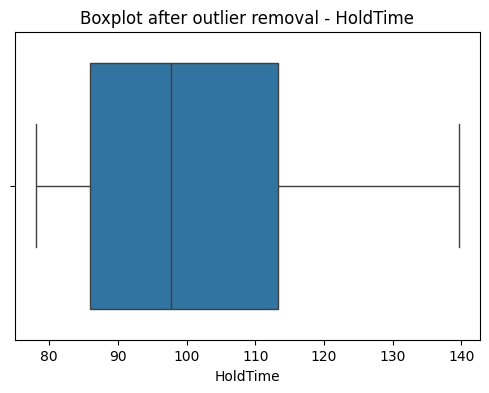

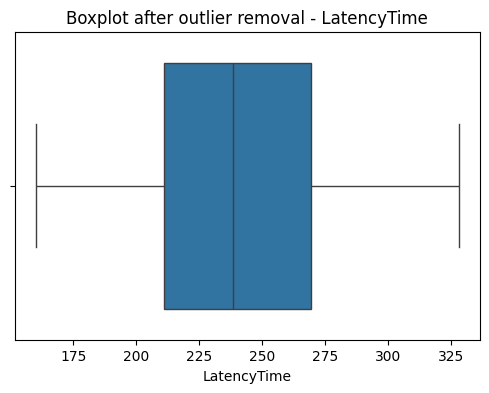

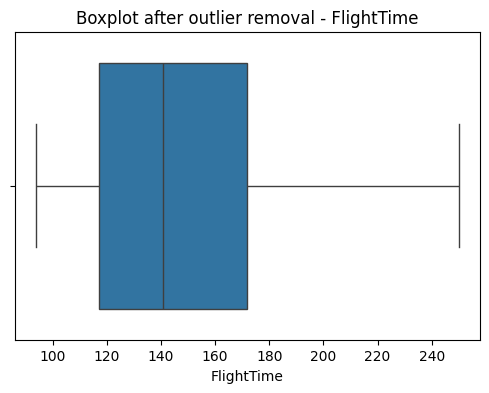

In [44]:
#Visulizing with box plots
import matplotlib.pyplot as plt
import seaborn as sns

for col in ["HoldTime", "LatencyTime", "FlightTime"]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot after outlier removal - {col}")
    plt.show()

In [45]:
num_columns

['Hand',
 'HoldTime',
 'Direction',
 'LatencyTime',
 'FlightTime',
 'UPDRS',
 'Ratio',
 'Latency-HoldTime']

In [46]:
#Scaling the numerical columns
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(df[num_columns])

data_scaled = scaler.fit_transform(df[num_columns])

print(scaler.mean_)

[  0.42964429 100.86522071   1.37655071 241.2353937  147.04567601
   0.2574913    0.72350548 140.370173  ]


In [47]:
#Keeping the preprocessed file another csv to facilate modeling

df.to_csv("modeling.csv", index=False)

In [48]:
#Visualizations 

import numpy as np


In [49]:
df

,Hand,HoldTime,Direction,LatencyTime,FlightTime,Parkinsons,UPDRS,Gender_Male,Ratio,Latency-HoldTime
0,0,101.6,0,234.4,156.3,True,0,False,0.650032,132.8
2,0,78.1,0,210.9,125.0,True,0,False,0.624800,132.8
6,1,85.9,1,195.3,117.2,True,0,False,0.732935,109.4
31,1,78.1,1,203.1,171.9,True,0,False,0.454334,125.0
40,0,78.1,0,203.1,132.8,True,0,False,0.588102,125.0
...,...,...,...,...,...,...,...,...,...,...
9316753,1,109.4,3,296.9,187.5,True,0,False,0.583467,187.5
9316811,1,132.8,3,320.3,156.3,True,0,False,0.849648,187.5
9316828,1,117.2,3,281.3,210.9,True,0,False,0.555714,164.1
9316841,1,109.4,3,203.1,93.8,True,0,False,1.166311,93.7


In [50]:
df["Parkinsons"].value_counts()

Parkinsons
True     740327
False    382709
Name: count, dtype: int64

In [51]:
#Making sure everything is consistent one more time 

for col in df.columns:

    print(col)

    print()

    print(df[col].unique())


Hand

[0 1]
HoldTime

[101.6  78.1  85.9  93.8 109.4 117.2 125.  128.9 121.1  89.8  82.   97.7
 138.7 113.3 105.5 132.8 136.7  87.9  99.6  80.1  95.7  91.8 111.3  90.8
 107.4 103.5 115.2  84.   94.7 119.1  90.   81.1 127.9 127.  110.4 106.4
 122.1 112.3 139.6 129.9 126.  131.8 134.8  98.6 130.9 123.  120.1 137.7
 116.2 116.9 116.  132.  103.  133.9 117.1 121.  101.  121.9 100.  120.
  98.  100.1 131.  129.  107.1 131.1 101.1 132.1 119.  128.2 106.9  92.8
  95.  135.  111.9  96.2 128.4 104.   86.9  79.1 104.5  96.7  88.9 135.7
 108.4 124.  136.   83.  102.5 100.6  85.  131.3 115.7 114.7 105.  107.9
  91.3 114.3  96.9  88.1 101.8  87.2 118.2 133.8 108.  102.  133.1 102.1
  79.8  98.1 114.   94.   93.  110.8 135.3  96.   92.  106.  122.  133.3
  79.6 111.8  94.2 112.8 109.9 108.9 136.2 113.8  93.3 134.3 129.4 130.4
 132.3  87.  110.   89.1 107.2  86.2 110.1 129.2 134.   97.2 120.8  91.1
 118.9  85.2  99.9  95.2 120.6  88.4 121.6 138.2  87.4  92.3  89.4 117.7
  90.3 139.2  89.   86.4 115. 

In [52]:
park_scaled = df["Parkinsons"]

In [53]:
park_scaled.isna().sum()

0

In [54]:
#Visualizations
import seaborn as sns
import matplotlib.pyplot as plt

Pairplot Visualizations

In [55]:
#plt_columns = ["HoldTime", "LatencyTime", "FlightTime", "Parkinsons"]
#sns.pairplot(df[plt_columns], hue="Parkinsons", diag_kind="kde")
#plt.show()

Heatmap Correlations

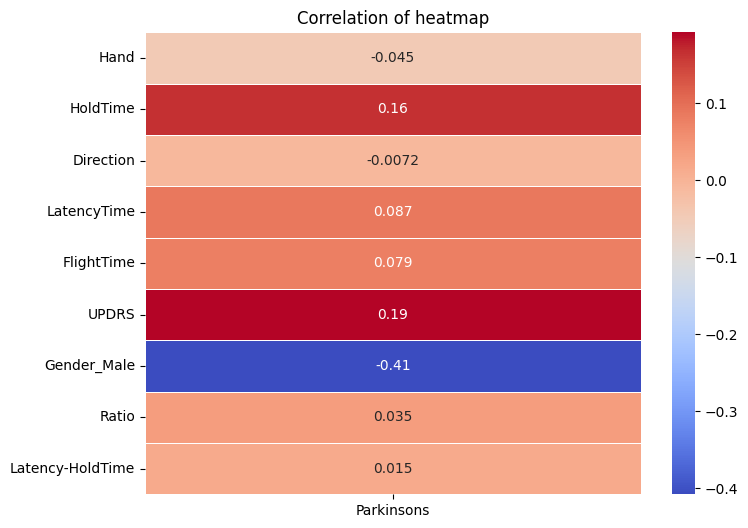

In [56]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr()[["Parkinsons"]].drop(index="Parkinsons"), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation of heatmap")
plt.show()


Histograms plotting for each feature

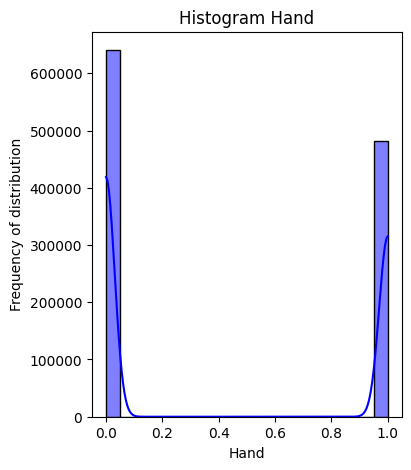

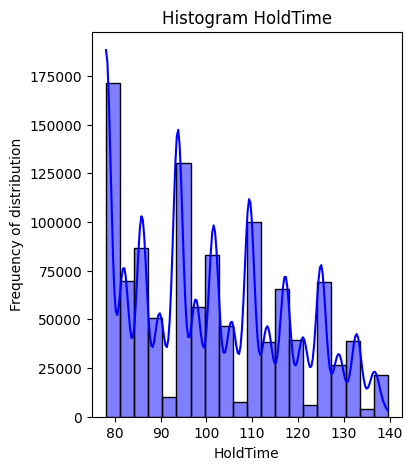

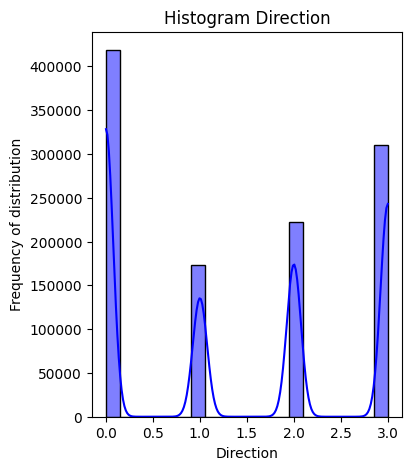

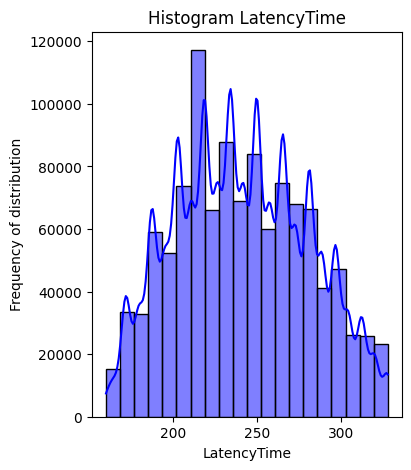

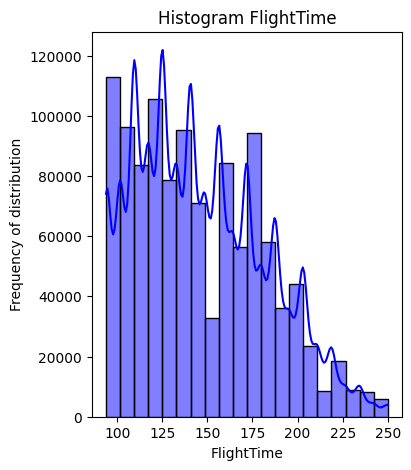

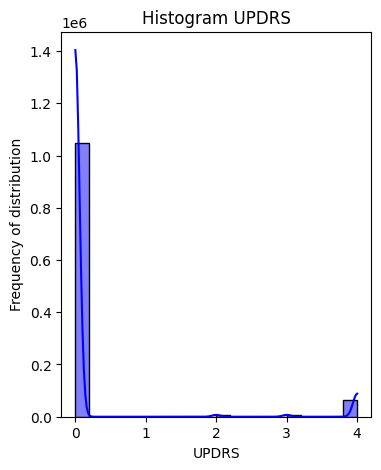

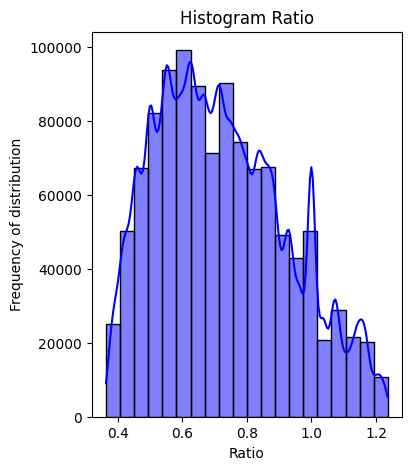

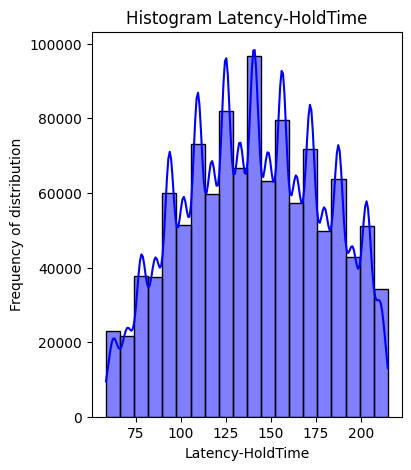

In [57]:
#Looping over num_columns for histogram plot
for col in num_columns:
    
    plt.figure(figsize=(4,5))
    sns.histplot(df[col], bins=20, kde=True, color="blue")
    plt.title("Histogram" + " " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency of distribution")
    plt.show()

Visualizations after preprocessing 

In [58]:
len(num_columns)
print(num_columns)

['Hand', 'HoldTime', 'Direction', 'LatencyTime', 'FlightTime', 'UPDRS', 'Ratio', 'Latency-HoldTime']


In [59]:
#Creating a dataframe with the scaled data and visualizing it again
df_scaled = pd.DataFrame(data=data_scaled, columns=num_columns)

df_scaled

,Hand,HoldTime,Direction,LatencyTime,FlightTime,UPDRS,Ratio,Latency-HoldTime
0,-0.867924,0.042861,-1.112192,-0.174363,0.261561,-0.266846,-0.364423,-0.197106
1,-0.867924,-1.327938,-1.112192,-0.773821,-0.623092,-0.266846,-0.489572,-0.197106
2,1.152175,-0.872949,-0.304236,-1.171758,-0.843549,-0.266846,0.046770,-0.806378
3,1.152175,-1.327938,-0.304236,-0.972789,0.702475,-0.266846,-1.335070,-0.400197
4,-0.867924,-1.327938,-1.112192,-0.972789,-0.402635,-0.266846,-0.671589,-0.400197
...,...,...,...,...,...,...,...,...
1123031,1.152175,0.497850,1.311675,1.419939,1.143389,-0.266846,-0.694582,1.227131
1123032,1.152175,1.862815,1.311675,2.016846,0.261561,-0.266846,0.625658,1.227131
1123033,1.152175,0.952838,1.311675,1.022001,1.804759,-0.266846,-0.832235,0.617859
1123034,1.152175,0.497850,1.311675,-0.972789,-1.504919,-0.266846,2.196283,-1.215162


Histogram visualizations

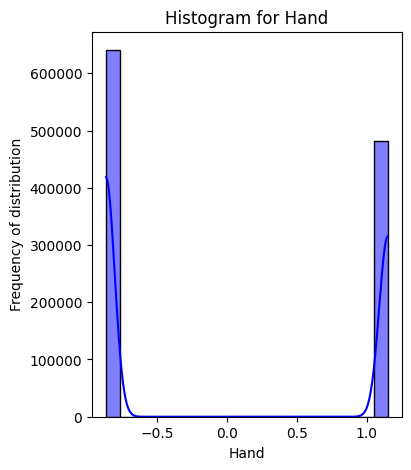

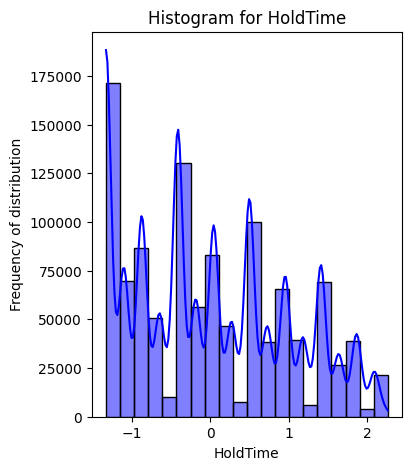

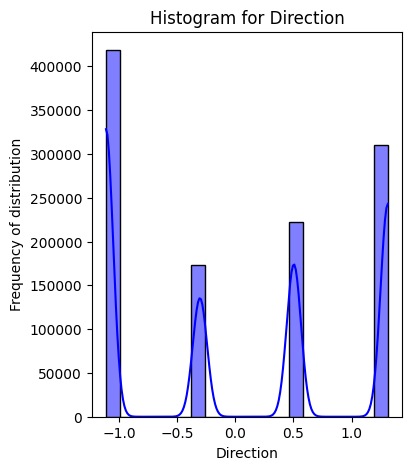

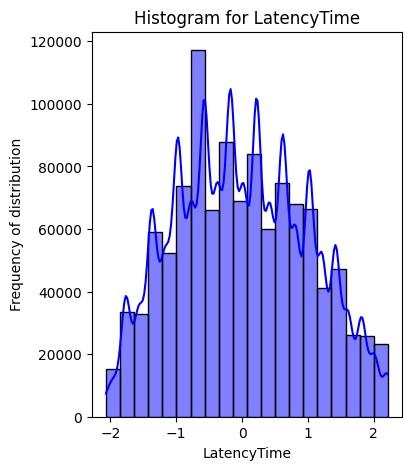

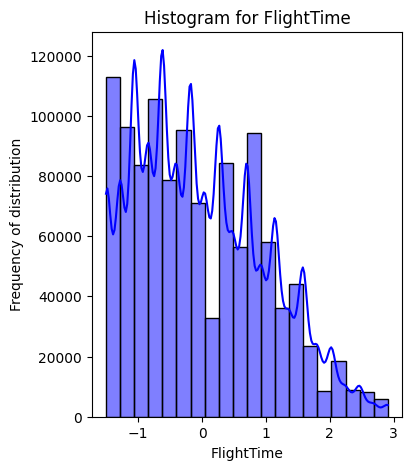

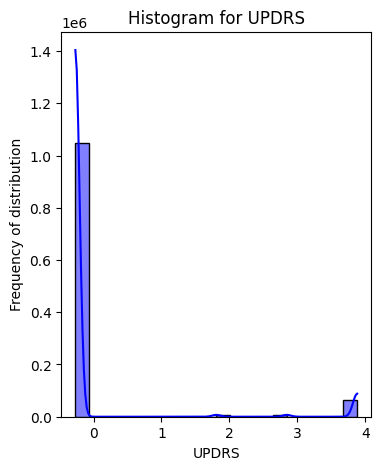

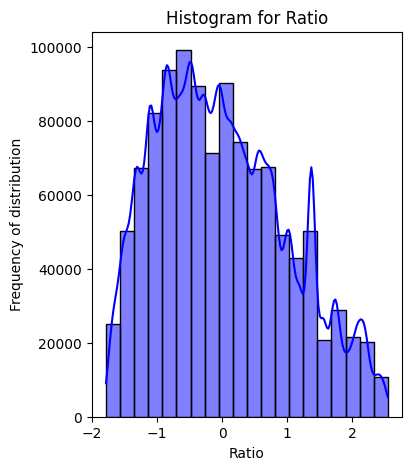

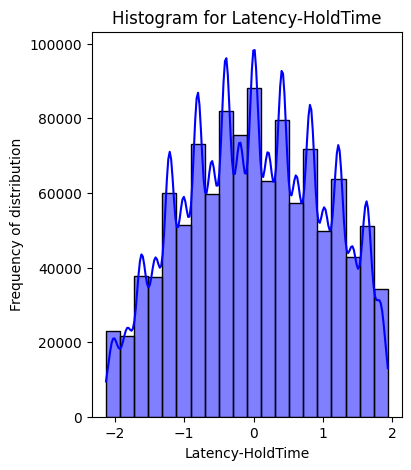

In [60]:
for col in num_columns:
    
    plt.figure(figsize=(4,5))
    sns.histplot(df_scaled[col], bins=20, kde=True, color="blue")
    plt.title("Histogram for" + " " + col)
    plt.xlabel(col)
    plt.ylabel("Frequency of distribution")
    plt.show()

Pairplot visualizations

Heatmap Visualizations

In [61]:
df_scaled["Parkinsons"] = park_scaled.reset_index(drop=True)

In [62]:
df_scaled["Parkinsons"].isna().sum()

0

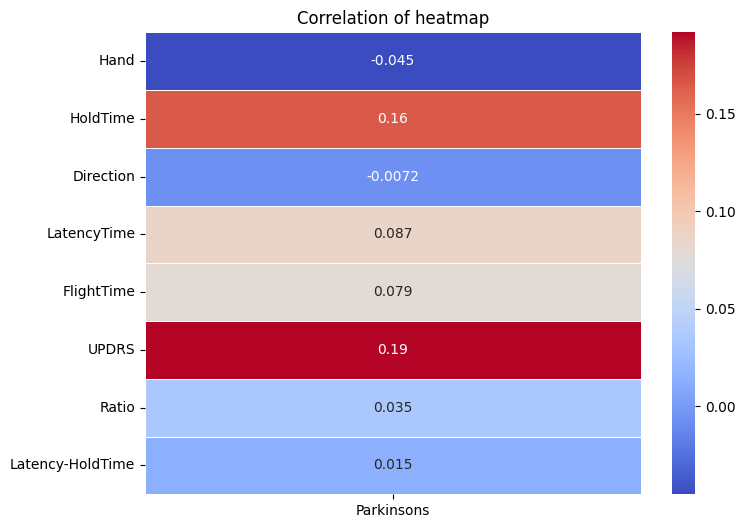

In [63]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_scaled.corr()[["Parkinsons"]].drop(index="Parkinsons"), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation of heatmap")
plt.show()


In [64]:
#Exporting this in the file directory for storage for a neural network

df_scaled.to_csv("nn.csv", index=False)